In [27]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [28]:
import os 
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

from statsmodels.stats.diagnostic import het_arch

In [29]:
from proj.features import transforms
from proj.data.storage import LocalStorage
from proj.evaluation.backtester import Backtester
from proj.evaluation.engine import greedy_forward_feature_selection, greedy_hyperparam_tuning, model_selection, evaluate_models
from proj.utils.paths import find_project_root, build_paths
from proj.data.merge_helpers import *


In [30]:
repo_root = find_project_root()
paths = build_paths(repo_root)

In [31]:
style_path = os.path.join(paths['SRC'], 'proj', 'utils', 'styler.mplstyle')
plt.style.use(style_path)

In [32]:
storage = LocalStorage(base_dir=Path("../data"))


In [33]:
df = storage.read_parquet("external/oos_predictions.parquet")

In [34]:
df

,truth,"EWMA(rv, λ=0.94)","GARCH(1,1)","GARCHProxyX(1,1,t,X=3)",HAR-RV,HAR-RV-X(3),XLE
date,,,,,,,
2025-01-07 21:00:00+00:00,1.368215,0.972945,0.932925,1.087559,1.292580,1.327953,42.548775
2025-01-08 21:00:00+00:00,1.351461,0.985658,0.938344,0.999477,1.133404,1.247763,42.592323
2025-01-10 21:00:00+00:00,1.701507,0.974931,0.923289,0.889200,1.017671,1.137057,42.766499
2025-01-13 21:00:00+00:00,1.804462,1.096545,0.905367,1.356086,1.555257,1.715814,43.666447
2025-01-14 21:00:00+00:00,1.514329,1.105876,0.897145,0.955379,1.199641,1.257126,44.135769
...,...,...,...,...,...,...,...
2026-01-02 21:00:00+00:00,0.294300,0.601679,0.972246,0.551593,0.333876,0.394488,45.650002
2026-01-05 21:00:00+00:00,0.784542,0.609997,1.025344,0.717135,0.531465,0.529460,46.889999
2026-01-06 21:00:00+00:00,1.077219,0.787947,1.233515,1.471883,1.247266,1.232384,45.639999


In [35]:
df = df.copy()

df["ret"] = df["XLE"].pct_change()
df = df.dropna(subset=["ret"])

In [36]:
def vol_target_strategy(
    ret: pd.Series,
    f_var: pd.Series,          # forecasted variance (annualized)
    target_ann_vol=0.14,
    w_min=0.0,
    w_max=6,
    eps=1e-12,
):
    f_sigma = np.sqrt(f_var.clip(lower=0) + eps)   # σ = sqrt(σ²)

    w = (target_ann_vol / f_sigma) ** 1.5
    w = w.clip(w_min, w_max)


    strat_ret = w.shift(1) * ret   # avoid lookahead
    equity = (1 + strat_ret.fillna(0)).cumprod()

    return pd.DataFrame({"w": w, "ret": strat_ret, "equity": equity})


In [37]:
vol_cols = [
    "EWMA(rv, λ=0.94)",
    "GARCH(1,1)",
    "GARCHProxyX(1,1,t,X=3)",
    "HAR-RV",
    "HAR-RV-X(3)",
]

results = {}

for col in vol_cols:
    results[col] = vol_target_strategy(
        ret=df["ret"],
        f_var=df[col],
        target_ann_vol=0.15,
    )


In [38]:
res = vol_target_strategy(df["ret"], df["HAR-RV-X(3)"], target_ann_vol=0.5, w_max=2.5)

print("avg weight:", res["w"].mean())
print("p90 weight:", res["w"].quantile(0.9))
print("realized ann vol:", res["ret"].std() * np.sqrt(252))


avg weight: 0.3927303434344984
p90 weight: 0.5510184410137503
realized ann vol: 0.0887094479245439


In [39]:
def performance_stats(strat_ret: pd.Series):
    ann_ret = strat_ret.mean() * 252
    ann_vol = strat_ret.std() * np.sqrt(252)
    sharpe = ann_ret / ann_vol if ann_vol > 0 else np.nan
    max_dd = (1 + strat_ret).cumprod().div(
        (1 + strat_ret).cumprod().cummax()
    ).min() - 1

    return pd.Series({
        "ann_return": ann_ret,
        "ann_vol": ann_vol,
        "sharpe": sharpe,
        "max_drawdown": max_dd,
    })


In [40]:
perf = pd.DataFrame({
    model: performance_stats(res["ret"])
    for model, res in results.items()
}).T

perf


,ann_return,ann_vol,sharpe,max_drawdown
"EWMA(rv, λ=0.94)",0.003568,0.012609,0.282951,-0.009703
"GARCH(1,1)",0.003174,0.012622,0.251475,-0.010509
"GARCHProxyX(1,1,t,X=3)",0.007604,0.014424,0.527183,-0.011911
HAR-RV,0.007578,0.015179,0.499269,-0.011669
HAR-RV-X(3),0.008603,0.014576,0.590171,-0.010977


In [41]:
xle_ret = df["ret"]

xle_equity = (1 + xle_ret.fillna(0)).cumprod()


In [42]:
comparison = {}

# Buy-and-hold
comparison["XLE Buy & Hold"] = performance_stats(xle_ret)

# Vol-targeted strategies
for model, res in results.items():
    comparison[f"VT – {model}"] = performance_stats(res["ret"])

perf_compare = pd.DataFrame(comparison).T
perf_compare


,ann_return,ann_vol,sharpe,max_drawdown
XLE Buy & Hold,0.121957,0.250655,0.486552,-0.187932
"VT – EWMA(rv, λ=0.94)",0.003568,0.012609,0.282951,-0.009703
"VT – GARCH(1,1)",0.003174,0.012622,0.251475,-0.010509
"VT – GARCHProxyX(1,1,t,X=3)",0.007604,0.014424,0.527183,-0.011911
VT – HAR-RV,0.007578,0.015179,0.499269,-0.011669
VT – HAR-RV-X(3),0.008603,0.014576,0.590171,-0.010977


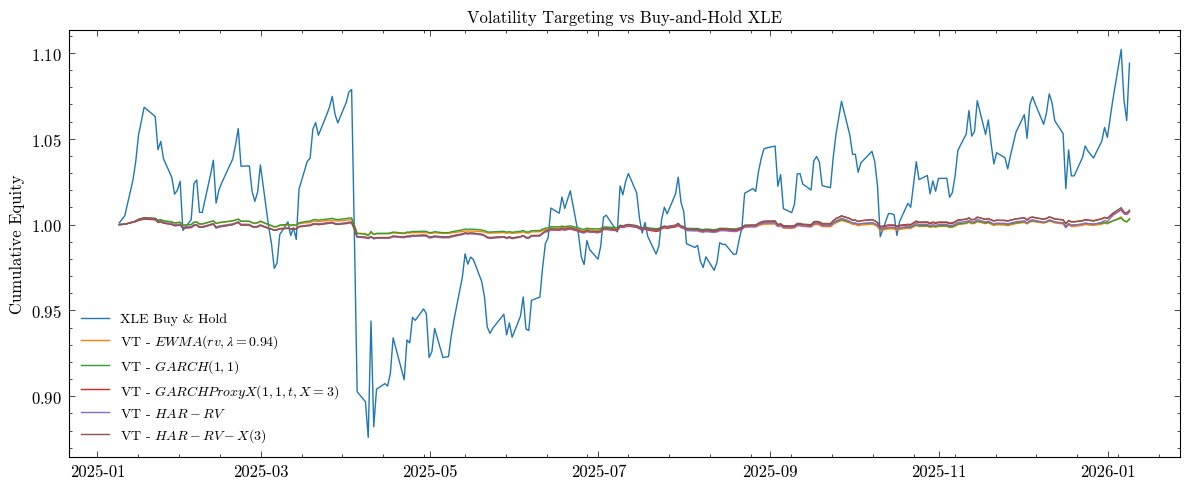

In [43]:

plt.figure(figsize=(12, 5))

plt.plot(xle_equity, label="XLE Buy & Hold")

for model, res in results.items():
    plt.plot(res["equity"], label=f"VT - ${model}$")

plt.legend()
plt.title("Volatility Targeting vs Buy-and-Hold XLE")
plt.ylabel("Cumulative Equity")
plt.tight_layout()
plt.show()
